# 02 — Brownian Motion, GBM, and Quadratic Variation

## Purpose

This notebook builds the stochastic-process foundation needed before returning to Black-Scholes, implied volatility, SVI, Heston, or Bates.

The goal is not to price options yet. The goal is to understand the object that continuous-time derivative pricing is built on:

> Brownian motion and the stock-price process generated from it.

In the failed v1.0 project, the calibration engine used continuous-time models before the stochastic foundation was fully controlled. This notebook fixes that gap.

---

## Core question

How do Brownian motion and geometric Brownian motion behave, and why does quadratic variation make ordinary calculus fail in continuous-time finance?

---

## What this notebook covers

1. Simulating Brownian motion paths  
2. Checking Brownian increment behavior  
3. Understanding time scaling  
4. Simulating geometric Brownian motion  
5. Verifying the lognormal terminal distribution of GBM  
6. Comparing arithmetic returns and log returns  
7. Demonstrating quadratic variation numerically  
8. Preparing the handoff to Ito's lemma and the Black-Scholes PDE  

---

## What this notebook does not prove

This notebook does **not** prove Black-Scholes.

It does **not** prove risk-neutral pricing.

It does **not** derive Ito's lemma.

It does **not** price options.

It only builds the stochastic-process foundation required before those steps.

---

## Main idea

A Brownian motion path looks noisy and irregular, but it has structure:

- increments are normally distributed,
- increments are independent over non-overlapping intervals,
- variance grows linearly with time,
- path variation is infinite in the ordinary sense,
- quadratic variation is finite and equals elapsed time.

That last point is the reason Ito calculus is needed.

In ordinary calculus, tiny squared changes disappear.  
In Brownian motion, tiny squared changes accumulate into something real.

That is why the Black-Scholes derivation cannot use ordinary chain rules.

---

## Pass condition

This notebook passes only if the simulations show the following:

1. Brownian terminal values have approximately the correct mean and variance.
2. Brownian increments behave approximately like independent normal shocks.
3. GBM terminal log-prices match the theoretical lognormal structure.
4. Quadratic variation converges toward elapsed time as the time grid becomes finer.
5. The notebook explains why this motivates Ito's lemma.

---

## Handoff

If this notebook passes, the next notebook is:

`03_ito_lemma_and_black_scholes_pde.ipynb`

That notebook will use the behavior observed here to explain why Ito's lemma modifies the ordinary chain rule and how that leads to the Black-Scholes PDE.

In [2]:
# ============================================================
# 02 — Brownian Motion, GBM, and Quadratic Variation
# Setup, imports, and notebook-wide configuration
# ============================================================

from __future__ import annotations

from dataclasses import dataclass
from typing import Final

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------
# Notebook display settings
# ----------------------------

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)


# ----------------------------
# Reproducibility
# ----------------------------

SEED: Final[int] = 620_02
rng = np.random.default_rng(SEED)


# ----------------------------
# Numerical tolerances
# ----------------------------

EXACT_TOL: Final[float] = 1e-10
STAT_TOL: Final[float] = 5e-2


# ----------------------------
# Simulation defaults
# ----------------------------

TRADING_DAYS: Final[int] = 252
DEFAULT_T: Final[float] = 1.0
DEFAULT_N_STEPS: Final[int] = TRADING_DAYS
DEFAULT_N_PATHS: Final[int] = 20_000


# ----------------------------
# Validation helpers
# ----------------------------

def require_positive(name: str, value: float) -> None:
    """Require a strictly positive scalar."""
    if not np.isfinite(value) or value <= 0:
        raise ValueError(f"{name} must be finite and strictly positive. Got {value}.")


def require_nonnegative(name: str, value: float) -> None:
    """Require a finite nonnegative scalar."""
    if not np.isfinite(value) or value < 0:
        raise ValueError(f"{name} must be finite and nonnegative. Got {value}.")


def require_integer_at_least(name: str, value: int, lower: int) -> None:
    """Require an integer greater than or equal to a lower bound."""
    if not isinstance(value, int) or value < lower:
        raise ValueError(f"{name} must be an integer >= {lower}. Got {value}.")


def summarize_array(values: np.ndarray, name: str) -> pd.DataFrame:
    """Return compact summary statistics for a numeric array."""
    flat = np.asarray(values, dtype=float).ravel()
    flat = flat[np.isfinite(flat)]

    if flat.size == 0:
        raise ValueError(f"{name} has no finite values to summarize.")

    return pd.DataFrame(
        {
            "name": [name],
            "count": [flat.size],
            "mean": [flat.mean()],
            "std": [flat.std(ddof=1)],
            "min": [flat.min()],
            "p01": [np.quantile(flat, 0.01)],
            "p05": [np.quantile(flat, 0.05)],
            "median": [np.median(flat)],
            "p95": [np.quantile(flat, 0.95)],
            "p99": [np.quantile(flat, 0.99)],
            "max": [flat.max()],
        }
    )


print("Setup complete.")
print(f"Seed: {SEED}")

Setup complete.
Seed: 62002


In [3]:
# ============================================================
# Brownian motion simulation primitives
# ============================================================

@dataclass(frozen=True)
class BrownianSimulationConfig:
    """Configuration for simulating standard Brownian motion paths."""

    T: float = DEFAULT_T
    n_steps: int = DEFAULT_N_STEPS
    n_paths: int = DEFAULT_N_PATHS

    def __post_init__(self) -> None:
        require_positive("T", self.T)
        require_integer_at_least("n_steps", self.n_steps, 1)
        require_integer_at_least("n_paths", self.n_paths, 1)

    @property
    def dt(self) -> float:
        """Length of one time step."""
        return self.T / self.n_steps

    @property
    def sqrt_dt(self) -> float:
        """Brownian increment scale."""
        return math.sqrt(self.dt)


def simulate_brownian_paths(
    config: BrownianSimulationConfig,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Simulate standard Brownian motion paths.

    Brownian motion is constructed from independent normal increments:

        dW_t ~ N(0, dt)

    Returns
    -------
    time_grid:
        Array of shape (n_steps + 1,).
    paths:
        Brownian paths with shape (n_paths, n_steps + 1).
    increments:
        Brownian increments with shape (n_paths, n_steps).
    """
    time_grid = np.linspace(0.0, config.T, config.n_steps + 1)

    increments = rng.normal(
        loc=0.0,
        scale=config.sqrt_dt,
        size=(config.n_paths, config.n_steps),
    )

    paths = np.empty((config.n_paths, config.n_steps + 1), dtype=float)
    paths[:, 0] = 0.0
    paths[:, 1:] = np.cumsum(increments, axis=1)

    return time_grid, paths, increments


brownian_config = BrownianSimulationConfig()
time_grid, brownian_paths, brownian_increments = simulate_brownian_paths(
    config=brownian_config,
    rng=rng,
)

brownian_setup_audit = pd.DataFrame(
    {
        "item": [
            "T",
            "n_steps",
            "dt",
            "n_paths",
            "paths_shape",
            "increments_shape",
            "initial_value_max_abs",
        ],
        "value": [
            brownian_config.T,
            brownian_config.n_steps,
            brownian_config.dt,
            brownian_config.n_paths,
            brownian_paths.shape,
            brownian_increments.shape,
            float(np.max(np.abs(brownian_paths[:, 0]))),
        ],
    }
)

brownian_setup_audit

,item,value
0,T,1.000000
1,n_steps,252
2,dt,0.003968
3,n_paths,20000
4,paths_shape,"(20000, 253)"
5,increments_shape,"(20000, 252)"
6,initial_value_max_abs,0.000000


,quantity,empirical,theoretical,absolute_error
0,terminal_mean,0.005543,0.000000,0.005543
1,terminal_variance,0.994561,1.000000,0.005439
2,terminal_std,0.997277,1.000000,0.002723


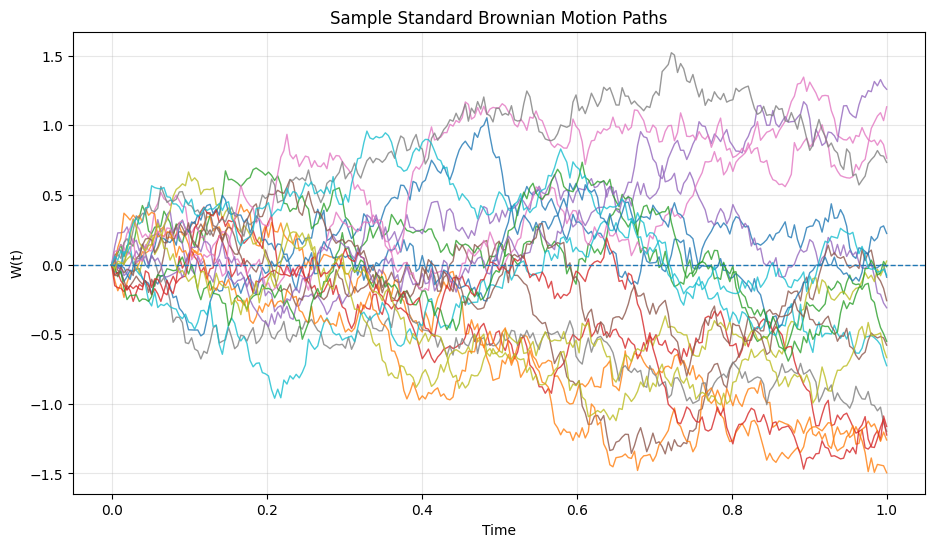

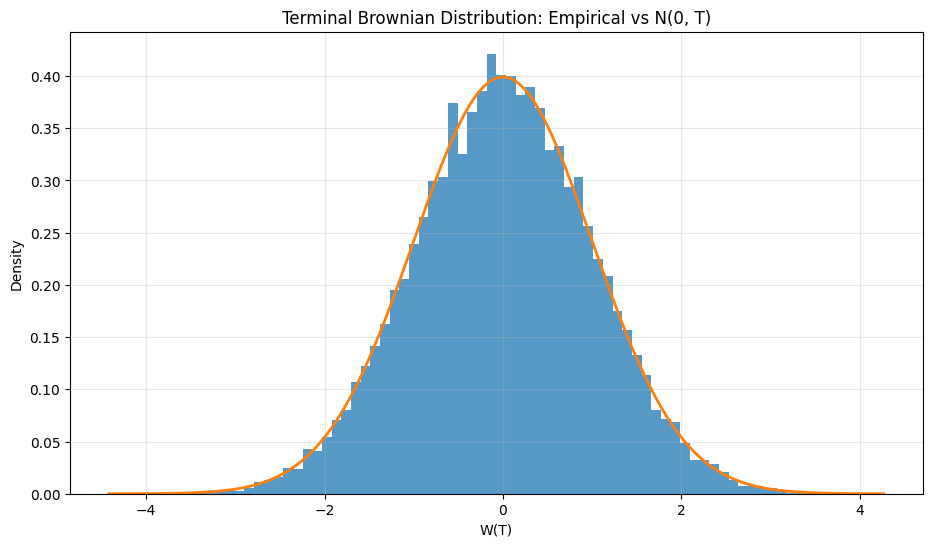

In [4]:
# ============================================================
# Brownian motion path visualization and terminal distribution check
# ============================================================

def brownian_terminal_audit(
    paths: np.ndarray,
    config: BrownianSimulationConfig,
) -> pd.DataFrame:
    """
    Check whether terminal Brownian values behave like W_T ~ N(0, T).

    For standard Brownian motion:
        E[W_T] = 0
        Var(W_T) = T
        Std(W_T) = sqrt(T)
    """
    terminal_values = paths[:, -1]

    empirical_mean = float(np.mean(terminal_values))
    empirical_var = float(np.var(terminal_values, ddof=1))
    empirical_std = float(np.std(terminal_values, ddof=1))

    theoretical_mean = 0.0
    theoretical_var = config.T
    theoretical_std = math.sqrt(config.T)

    return pd.DataFrame(
        {
            "quantity": [
                "terminal_mean",
                "terminal_variance",
                "terminal_std",
            ],
            "empirical": [
                empirical_mean,
                empirical_var,
                empirical_std,
            ],
            "theoretical": [
                theoretical_mean,
                theoretical_var,
                theoretical_std,
            ],
            "absolute_error": [
                abs(empirical_mean - theoretical_mean),
                abs(empirical_var - theoretical_var),
                abs(empirical_std - theoretical_std),
            ],
        }
    )


terminal_audit = brownian_terminal_audit(
    paths=brownian_paths,
    config=brownian_config,
)

display(terminal_audit)


# Plot a small number of paths only. Plotting all paths would be visual noise.
n_plot_paths = 20

plt.figure(figsize=(11, 6))
for path_idx in range(n_plot_paths):
    plt.plot(time_grid, brownian_paths[path_idx], linewidth=1.0, alpha=0.8)

plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.title("Sample Standard Brownian Motion Paths")
plt.xlabel("Time")
plt.ylabel("W(t)")
plt.grid(True, alpha=0.3)
plt.show()


# Terminal distribution check
terminal_values = brownian_paths[:, -1]

plt.figure(figsize=(11, 6))
plt.hist(terminal_values, bins=80, density=True, alpha=0.75)

x_grid = np.linspace(
    terminal_values.min(),
    terminal_values.max(),
    500,
)
normal_density = (
    1.0 / math.sqrt(2.0 * math.pi * brownian_config.T)
    * np.exp(-(x_grid**2) / (2.0 * brownian_config.T))
)

plt.plot(x_grid, normal_density, linewidth=2.0)
plt.title("Terminal Brownian Distribution: Empirical vs N(0, T)")
plt.xlabel("W(T)")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.show()

,quantity,empirical,theoretical,absolute_error
0,increment_mean,0.000022,0.000000,0.000022
1,increment_variance,0.003971,0.003968,0.000003
2,increment_std,0.063016,0.062994,0.000022
3,standardized_increment_mean,0.000349,0.000000,0.000349
4,standardized_increment_variance,1.000700,1.000000,0.000700
5,standardized_increment_std,1.000350,1.000000,0.000350
6,adjacent_increment_corr,0.000506,0.000000,0.000506
7,lag_5_increment_corr,0.000803,0.000000,0.000803
8,max_abs_step_mean,0.001442,0.000000,0.001442
9,mean_abs_variance_error_by_step,0.000034,0.000000,0.000034


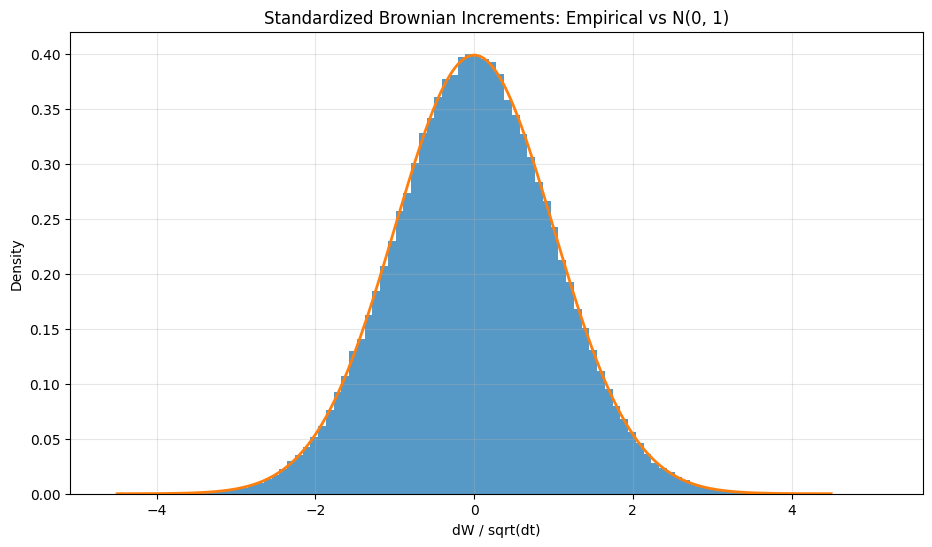

In [5]:
# ============================================================
# Brownian increment diagnostics
# ============================================================

def pearson_corr(x: np.ndarray, y: np.ndarray) -> float:
    """Compute Pearson correlation without building a large correlation matrix."""
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    if x.shape != y.shape:
        raise ValueError(f"x and y must have the same shape. Got {x.shape} and {y.shape}.")

    x_centered = x - x.mean()
    y_centered = y - y.mean()

    denominator = math.sqrt(float(np.sum(x_centered**2) * np.sum(y_centered**2)))
    if denominator <= 0:
        raise ValueError("Cannot compute correlation with zero variance input.")

    return float(np.sum(x_centered * y_centered) / denominator)


def brownian_increment_audit(
    increments: np.ndarray,
    config: BrownianSimulationConfig,
) -> pd.DataFrame:
    """
    Audit Brownian increments.

    For standard Brownian motion:
        W(t + dt) - W(t) ~ N(0, dt)

    Therefore standardized increments:
        [W(t + dt) - W(t)] / sqrt(dt)

    should behave like N(0, 1).
    """
    flat_increments = increments.ravel()
    standardized = flat_increments / config.sqrt_dt

    adjacent_corr = pearson_corr(
        increments[:, :-1],
        increments[:, 1:],
    )

    lag_5_corr = pearson_corr(
        increments[:, :-5],
        increments[:, 5:],
    )

    step_means = increments.mean(axis=0)
    step_variances = increments.var(axis=0, ddof=1)

    return pd.DataFrame(
        {
            "quantity": [
                "increment_mean",
                "increment_variance",
                "increment_std",
                "standardized_increment_mean",
                "standardized_increment_variance",
                "standardized_increment_std",
                "adjacent_increment_corr",
                "lag_5_increment_corr",
                "max_abs_step_mean",
                "mean_abs_variance_error_by_step",
            ],
            "empirical": [
                float(flat_increments.mean()),
                float(flat_increments.var(ddof=1)),
                float(flat_increments.std(ddof=1)),
                float(standardized.mean()),
                float(standardized.var(ddof=1)),
                float(standardized.std(ddof=1)),
                adjacent_corr,
                lag_5_corr,
                float(np.max(np.abs(step_means))),
                float(np.mean(np.abs(step_variances - config.dt))),
            ],
            "theoretical": [
                0.0,
                config.dt,
                config.sqrt_dt,
                0.0,
                1.0,
                1.0,
                0.0,
                0.0,
                0.0,
                0.0,
            ],
        }
    ).assign(
        absolute_error=lambda df: (df["empirical"] - df["theoretical"]).abs()
    )


increment_audit = brownian_increment_audit(
    increments=brownian_increments,
    config=brownian_config,
)

display(increment_audit)


# Use a subsample for plotting so the histogram stays responsive.
standardized_increments = brownian_increments.ravel() / brownian_config.sqrt_dt
hist_sample_size = min(300_000, standardized_increments.size)
hist_sample_idx = rng.choice(
    standardized_increments.size,
    size=hist_sample_size,
    replace=False,
)
standardized_hist_sample = standardized_increments[hist_sample_idx]

plt.figure(figsize=(11, 6))
plt.hist(standardized_hist_sample, bins=100, density=True, alpha=0.75)

x_grid = np.linspace(-4.5, 4.5, 500)
standard_normal_density = (
    1.0 / math.sqrt(2.0 * math.pi)
    * np.exp(-(x_grid**2) / 2.0)
)

plt.plot(x_grid, standard_normal_density, linewidth=2.0)
plt.title("Standardized Brownian Increments: Empirical vs N(0, 1)")
plt.xlabel("dW / sqrt(dt)")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.show()

,target_time,grid_time,empirical_mean,theoretical_mean,mean_abs_error,empirical_variance,theoretical_variance,variance_abs_error,empirical_std,theoretical_std,std_abs_error
0,0.250000,0.250000,0.002802,0.000000,0.002802,0.251938,0.250000,0.001938,0.501934,0.500000,0.001934
1,0.500000,0.500000,0.009505,0.000000,0.009505,0.492256,0.500000,0.007744,0.701610,0.707107,0.005497
2,0.750000,0.750000,0.006796,0.000000,0.006796,0.745680,0.750000,0.004320,0.863528,0.866025,0.002498
3,1.000000,1.000000,0.005543,0.000000,0.005543,0.994561,1.000000,0.005439,0.997277,1.000000,0.002723


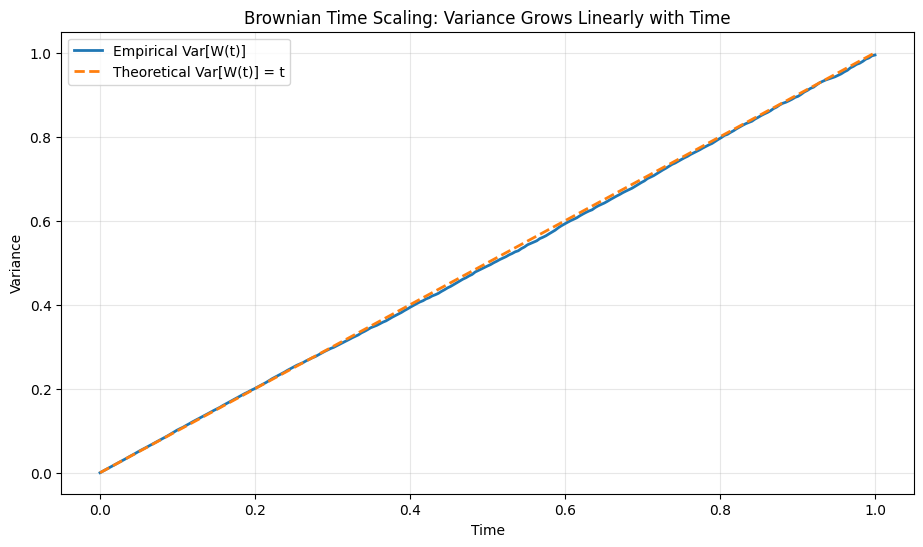

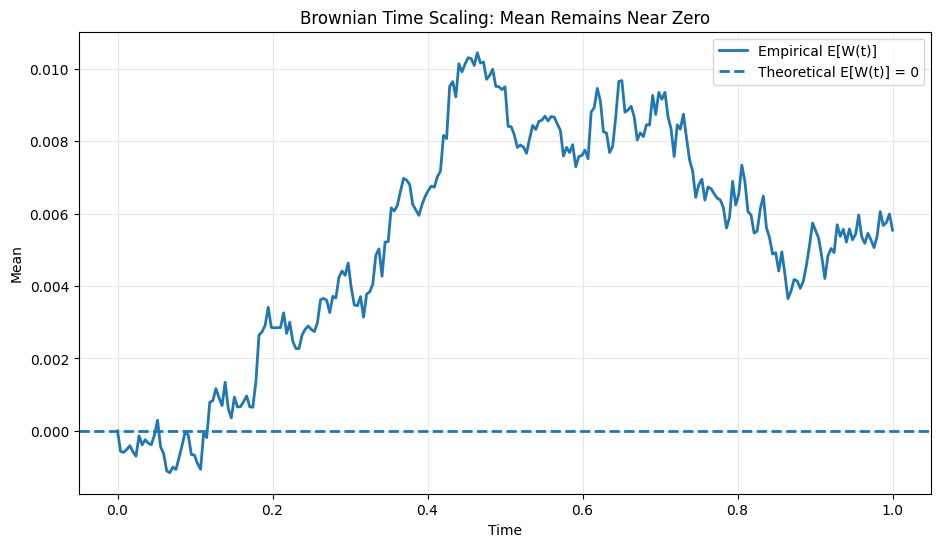

In [6]:
# ============================================================
# Brownian time-scaling diagnostics
# ============================================================

def brownian_time_scaling_audit(
    paths: np.ndarray,
    time_grid: np.ndarray,
    checkpoints: list[float],
) -> pd.DataFrame:
    """
    Check Brownian time scaling.

    For standard Brownian motion:
        W_t ~ N(0, t)

    Therefore:
        E[W_t] = 0
        Var(W_t) = t
        Std(W_t) = sqrt(t)
    """
    rows: list[dict[str, float]] = []

    for checkpoint in checkpoints:
        if checkpoint < 0 or checkpoint > time_grid[-1]:
            raise ValueError(
                f"checkpoint must be inside [0, {time_grid[-1]}]. Got {checkpoint}."
            )

        idx = int(np.argmin(np.abs(time_grid - checkpoint)))
        t = float(time_grid[idx])
        values = paths[:, idx]

        empirical_mean = float(values.mean())
        empirical_var = float(values.var(ddof=1))
        empirical_std = float(values.std(ddof=1))

        rows.append(
            {
                "target_time": checkpoint,
                "grid_time": t,
                "empirical_mean": empirical_mean,
                "theoretical_mean": 0.0,
                "mean_abs_error": abs(empirical_mean),
                "empirical_variance": empirical_var,
                "theoretical_variance": t,
                "variance_abs_error": abs(empirical_var - t),
                "empirical_std": empirical_std,
                "theoretical_std": math.sqrt(t),
                "std_abs_error": abs(empirical_std - math.sqrt(t)),
            }
        )

    return pd.DataFrame(rows)


time_scaling_checkpoints = [0.25, 0.50, 0.75, 1.00]

time_scaling_audit = brownian_time_scaling_audit(
    paths=brownian_paths,
    time_grid=time_grid,
    checkpoints=time_scaling_checkpoints,
)

display(time_scaling_audit)


# Estimate variance across every time point.
path_means_by_time = brownian_paths.mean(axis=0)
path_variances_by_time = brownian_paths.var(axis=0, ddof=1)

plt.figure(figsize=(11, 6))
plt.plot(time_grid, path_variances_by_time, linewidth=2.0, label="Empirical Var[W(t)]")
plt.plot(time_grid, time_grid, linestyle="--", linewidth=2.0, label="Theoretical Var[W(t)] = t")
plt.title("Brownian Time Scaling: Variance Grows Linearly with Time")
plt.xlabel("Time")
plt.ylabel("Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(11, 6))
plt.plot(time_grid, path_means_by_time, linewidth=2.0, label="Empirical E[W(t)]")
plt.axhline(0.0, linestyle="--", linewidth=2.0, label="Theoretical E[W(t)] = 0")
plt.title("Brownian Time Scaling: Mean Remains Near Zero")
plt.xlabel("Time")
plt.ylabel("Mean")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

,n_steps,dt,qv_mean,qv_theoretical_mean,qv_mean_abs_error,qv_std,qv_theoretical_std,abs_variation_mean,abs_variation_theoretical_mean,abs_variation_std
0,16,0.062500,0.995188,1.000000,0.004812,0.344503,0.353553,3.185424,3.191538,0.595403
1,32,0.031250,0.993130,1.000000,0.006870,0.248235,0.250000,4.496916,4.513517,0.600369
2,64,0.015625,0.996957,1.000000,0.003043,0.176221,0.176777,6.369310,6.383076,0.602554
3,128,0.007812,0.999156,1.000000,0.000844,0.127841,0.125000,9.025422,9.027033,0.607059
4,252,0.003968,1.002605,1.000000,0.002605,0.088792,0.089087,12.682338,12.666025,0.602302
5,512,0.001953,0.998271,1.000000,0.001729,0.061370,0.062500,18.048309,18.054067,0.594056
6,1024,0.000977,1.000055,1.000000,0.000055,0.043634,0.044194,25.539030,25.532306,0.590845
7,2048,0.000488,1.000161,1.000000,0.000161,0.031991,0.031250,36.113581,36.108133,0.615525
8,4096,0.000244,1.000204,1.000000,0.000204,0.021675,0.022097,51.068116,51.064612,0.593694


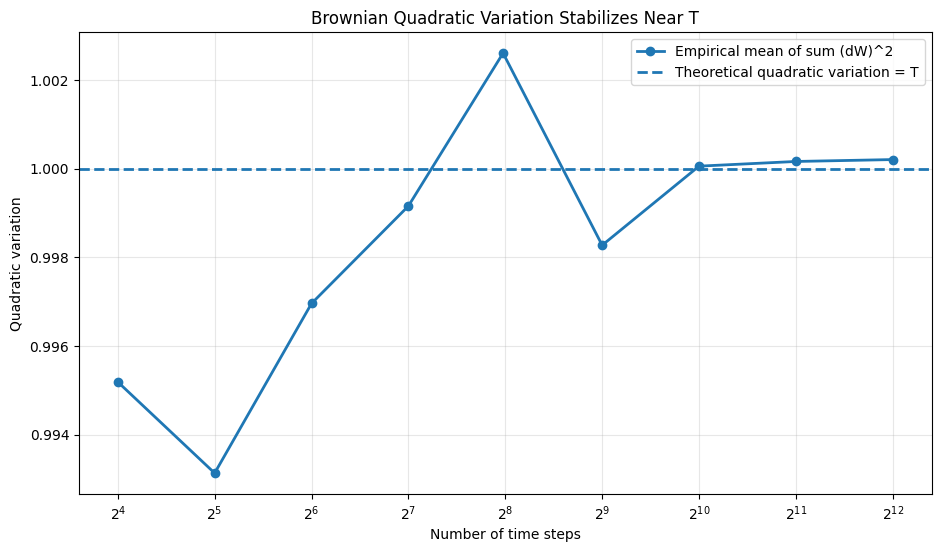

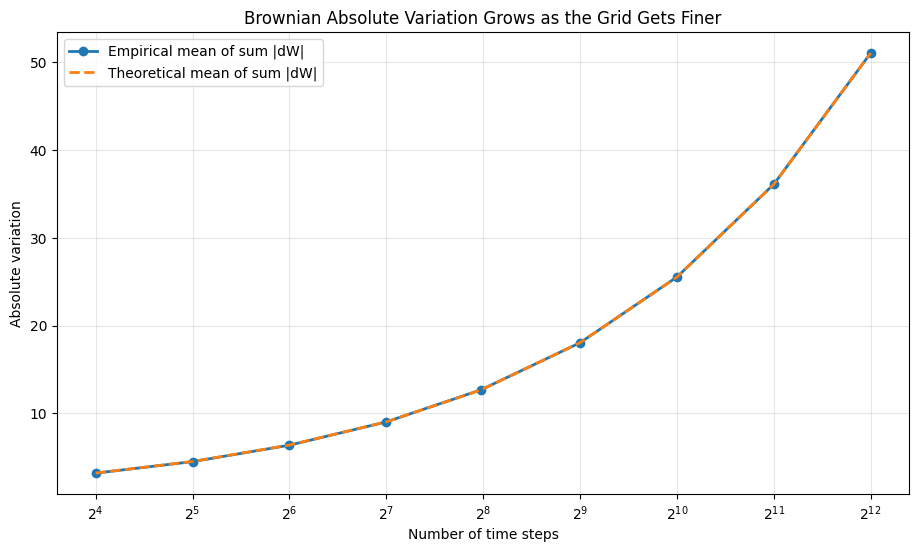

In [7]:
# ============================================================
# Quadratic variation diagnostics
# ============================================================

def realized_variation_audit(
    T: float,
    n_steps_grid: list[int],
    n_paths: int,
    rng: np.random.Generator,
) -> pd.DataFrame:
    """
    Compare ordinary path variation and quadratic variation.

    For Brownian motion over [0, T]:

        Quadratic variation:
            sum (dW)^2 -> T

        Absolute variation:
            sum |dW| grows as the grid becomes finer

    This is the numerical reason ordinary calculus fails for Brownian paths,
    while Ito calculus keeps the second-order term.
    """
    require_positive("T", T)
    require_integer_at_least("n_paths", n_paths, 1)

    rows: list[dict[str, float]] = []

    for n_steps in n_steps_grid:
        require_integer_at_least("n_steps", n_steps, 1)

        dt = T / n_steps
        sqrt_dt = math.sqrt(dt)

        increments = rng.normal(
            loc=0.0,
            scale=sqrt_dt,
            size=(n_paths, n_steps),
        )

        quadratic_variation = np.sum(increments**2, axis=1)
        absolute_variation = np.sum(np.abs(increments), axis=1)

        theoretical_qv_mean = T
        theoretical_qv_std = math.sqrt(2.0 * (T**2) / n_steps)

        theoretical_abs_var_mean = n_steps * sqrt_dt * math.sqrt(2.0 / math.pi)

        rows.append(
            {
                "n_steps": n_steps,
                "dt": dt,
                "qv_mean": float(quadratic_variation.mean()),
                "qv_theoretical_mean": theoretical_qv_mean,
                "qv_mean_abs_error": abs(float(quadratic_variation.mean()) - theoretical_qv_mean),
                "qv_std": float(quadratic_variation.std(ddof=1)),
                "qv_theoretical_std": theoretical_qv_std,
                "abs_variation_mean": float(absolute_variation.mean()),
                "abs_variation_theoretical_mean": theoretical_abs_var_mean,
                "abs_variation_std": float(absolute_variation.std(ddof=1)),
            }
        )

    return pd.DataFrame(rows)


qv_steps_grid = [16, 32, 64, 128, 252, 512, 1_024, 2_048, 4_096]
qv_n_paths = 3_000
qv_rng = np.random.default_rng(SEED + 10_000)

variation_audit = realized_variation_audit(
    T=DEFAULT_T,
    n_steps_grid=qv_steps_grid,
    n_paths=qv_n_paths,
    rng=qv_rng,
)

display(variation_audit)


plt.figure(figsize=(11, 6))
plt.plot(
    variation_audit["n_steps"],
    variation_audit["qv_mean"],
    marker="o",
    linewidth=2.0,
    label="Empirical mean of sum (dW)^2",
)
plt.axhline(DEFAULT_T, linestyle="--", linewidth=2.0, label="Theoretical quadratic variation = T")
plt.xscale("log", base=2)
plt.title("Brownian Quadratic Variation Stabilizes Near T")
plt.xlabel("Number of time steps")
plt.ylabel("Quadratic variation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(11, 6))
plt.plot(
    variation_audit["n_steps"],
    variation_audit["abs_variation_mean"],
    marker="o",
    linewidth=2.0,
    label="Empirical mean of sum |dW|",
)
plt.plot(
    variation_audit["n_steps"],
    variation_audit["abs_variation_theoretical_mean"],
    linestyle="--",
    linewidth=2.0,
    label="Theoretical mean of sum |dW|",
)
plt.xscale("log", base=2)
plt.title("Brownian Absolute Variation Grows as the Grid Gets Finer")
plt.xlabel("Number of time steps")
plt.ylabel("Absolute variation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

,n_steps,dt,qv_mean,qv_std,qv_theoretical_mean,qv_mean_abs_error,abs_variation_mean,abs_variation_std,abs_variation_theoretical_mean
0,16,0.062500,1.000950,0.356882,1.000000,0.000950,3.190630,0.607733,3.191538
1,32,0.031250,1.007584,0.256744,1.000000,0.007584,4.525445,0.603343,4.513517
2,64,0.015625,1.000483,0.183652,1.000000,0.000483,6.375245,0.619992,6.383076
3,128,0.007812,0.997999,0.127961,1.000000,0.002001,9.015330,0.616417,9.027033
4,256,0.003906,0.999141,0.090739,1.000000,0.000859,12.761333,0.613719,12.766153
5,512,0.001953,1.000831,0.062077,1.000000,0.000831,18.061506,0.598377,18.054067
6,1024,0.000977,1.000328,0.043311,1.000000,0.000328,25.542777,0.591480,25.532306
7,2048,0.000488,1.000842,0.030318,1.000000,0.000842,36.124842,0.582179,36.108133
8,4096,0.000244,0.999892,0.021731,1.000000,0.000108,51.057873,0.588594,51.064612


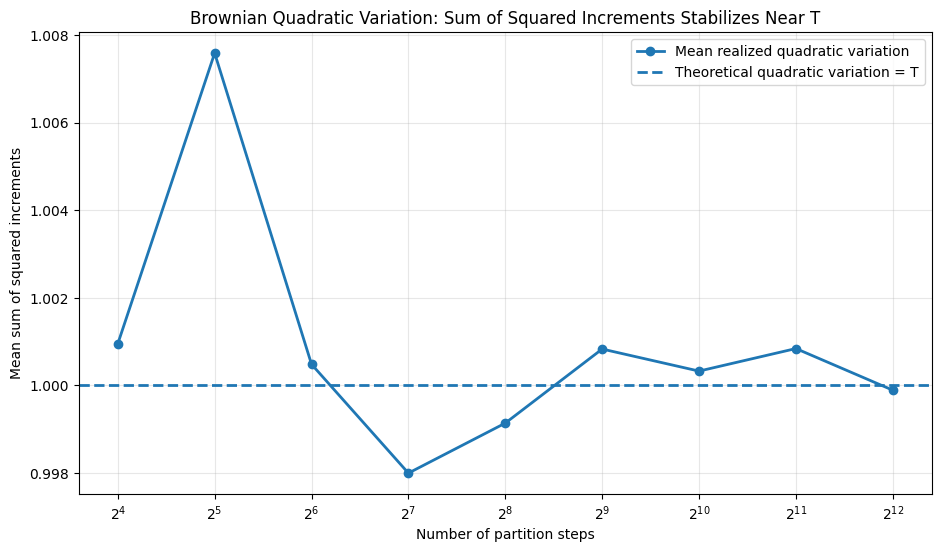

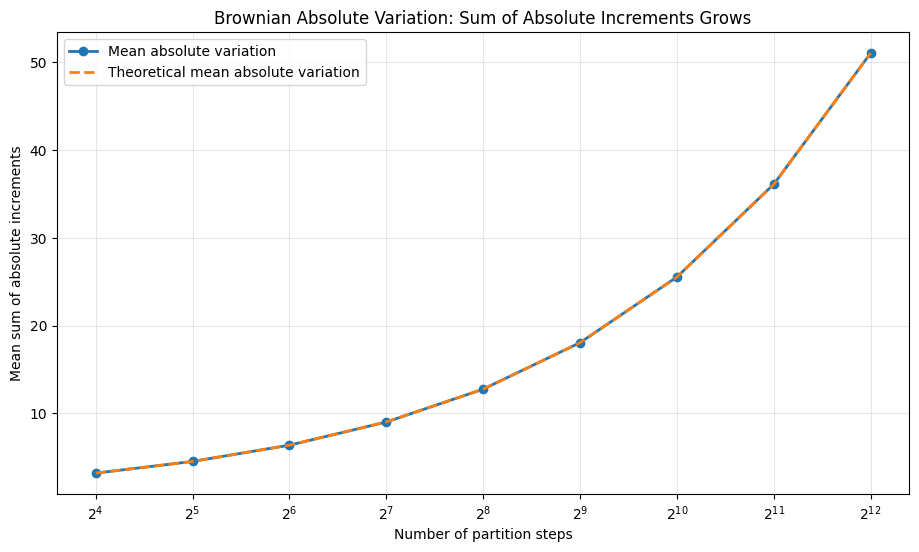

,diagnostic,result
0,quadratic_variation,sum (dW)^2 remains near T as the partition get...
1,absolute_variation,sum |dW| grows as the partition gets finer
2,ito_motivation,"second-order Brownian terms do not vanish, so ..."


In [8]:
# ============================================================
# Quadratic variation diagnostics
# ============================================================

def nested_realized_variation_audit(
    T: float,
    n_fine_steps: int,
    n_paths: int,
    partition_steps: list[int],
    rng: np.random.Generator,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """
    Demonstrate Brownian quadratic variation using nested partitions.

    This cell simulates Brownian motion on one fine grid, then aggregates
    those same paths into coarser partitions.

    That is important: the partitions are nested refinements of the same
    Brownian paths, not unrelated simulations at each step count.

    For Brownian motion over [0, T]:

        sum (dW)^2 -> T

    but

        sum |dW| grows as the grid gets finer.

    This is the numerical motivation for Ito calculus.
    """
    require_positive("T", T)
    require_integer_at_least("n_fine_steps", n_fine_steps, 1)
    require_integer_at_least("n_paths", n_paths, 1)

    for n_steps in partition_steps:
        require_integer_at_least("partition n_steps", n_steps, 1)
        if n_fine_steps % n_steps != 0:
            raise ValueError(
                f"Each partition step count must divide n_fine_steps. "
                f"Got n_fine_steps={n_fine_steps}, n_steps={n_steps}."
            )

    fine_dt = T / n_fine_steps
    fine_increments = rng.normal(
        loc=0.0,
        scale=math.sqrt(fine_dt),
        size=(n_paths, n_fine_steps),
    )

    rows: list[dict[str, float]] = []

    for n_steps in partition_steps:
        block_size = n_fine_steps // n_steps

        coarse_increments = fine_increments.reshape(
            n_paths,
            n_steps,
            block_size,
        ).sum(axis=2)

        quadratic_variation = np.sum(coarse_increments**2, axis=1)
        absolute_variation = np.sum(np.abs(coarse_increments), axis=1)

        dt = T / n_steps

        rows.append(
            {
                "n_steps": n_steps,
                "dt": dt,
                "qv_mean": float(quadratic_variation.mean()),
                "qv_std": float(quadratic_variation.std(ddof=1)),
                "qv_theoretical_mean": T,
                "qv_mean_abs_error": abs(float(quadratic_variation.mean()) - T),
                "abs_variation_mean": float(absolute_variation.mean()),
                "abs_variation_std": float(absolute_variation.std(ddof=1)),
                "abs_variation_theoretical_mean": float(
                    n_steps * math.sqrt(dt) * math.sqrt(2.0 / math.pi)
                ),
            }
        )

    audit = pd.DataFrame(rows)

    fine_paths = np.empty((n_paths, n_fine_steps + 1), dtype=float)
    fine_paths[:, 0] = 0.0
    fine_paths[:, 1:] = np.cumsum(fine_increments, axis=1)

    return audit, fine_paths, fine_increments


qv_partition_steps = [16, 32, 64, 128, 256, 512, 1_024, 2_048, 4_096]
qv_n_fine_steps = 4_096
qv_n_paths = 2_000
qv_rng = np.random.default_rng(SEED + 20_000)

variation_audit, qv_paths, qv_fine_increments = nested_realized_variation_audit(
    T=DEFAULT_T,
    n_fine_steps=qv_n_fine_steps,
    n_paths=qv_n_paths,
    partition_steps=qv_partition_steps,
    rng=qv_rng,
)

display(variation_audit)


plt.figure(figsize=(11, 6))
plt.plot(
    variation_audit["n_steps"],
    variation_audit["qv_mean"],
    marker="o",
    linewidth=2.0,
    label="Mean realized quadratic variation",
)
plt.axhline(
    DEFAULT_T,
    linestyle="--",
    linewidth=2.0,
    label="Theoretical quadratic variation = T",
)
plt.xscale("log", base=2)
plt.title("Brownian Quadratic Variation: Sum of Squared Increments Stabilizes Near T")
plt.xlabel("Number of partition steps")
plt.ylabel("Mean sum of squared increments")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(11, 6))
plt.plot(
    variation_audit["n_steps"],
    variation_audit["abs_variation_mean"],
    marker="o",
    linewidth=2.0,
    label="Mean absolute variation",
)
plt.plot(
    variation_audit["n_steps"],
    variation_audit["abs_variation_theoretical_mean"],
    linestyle="--",
    linewidth=2.0,
    label="Theoretical mean absolute variation",
)
plt.xscale("log", base=2)
plt.title("Brownian Absolute Variation: Sum of Absolute Increments Grows")
plt.xlabel("Number of partition steps")
plt.ylabel("Mean sum of absolute increments")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


qv_interpretation = pd.DataFrame(
    {
        "diagnostic": [
            "quadratic_variation",
            "absolute_variation",
            "ito_motivation",
        ],
        "result": [
            "sum (dW)^2 remains near T as the partition gets finer",
            "sum |dW| grows as the partition gets finer",
            "second-order Brownian terms do not vanish, so ordinary calculus is not enough",
        ],
    }
)

qv_interpretation

,quantity,empirical,theoretical,absolute_error
0,terminal_log_return_mean,0.059033,0.060000,0.000967
1,terminal_log_return_variance,0.040407,0.040000,0.000407
2,terminal_log_return_std,0.201014,0.200000,0.001014
3,terminal_price_mean,108.250453,108.328707,0.078253
4,terminal_price_median,105.799236,106.183655,0.384418


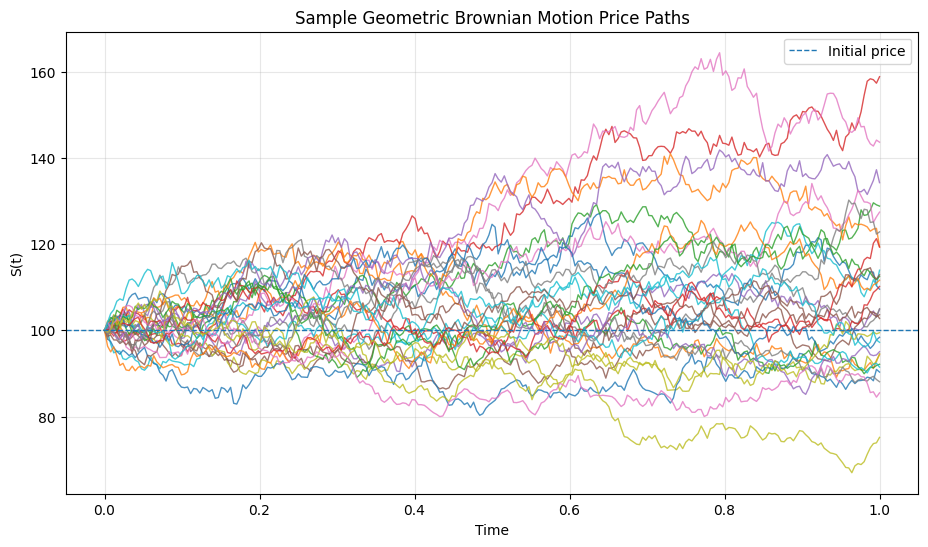

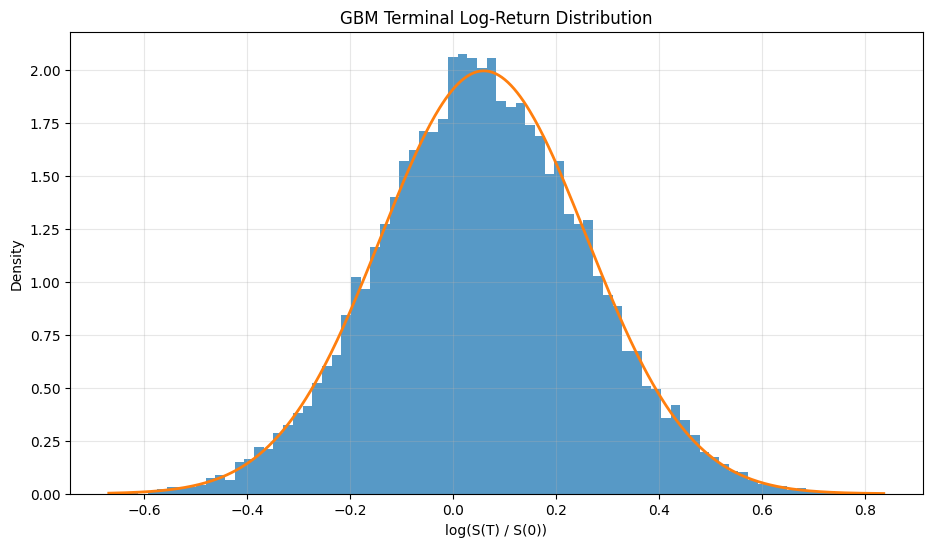

In [9]:
# ============================================================
# Geometric Brownian motion simulation
# ============================================================

@dataclass(frozen=True)
class GBMSimulationConfig:
    """
    Configuration for geometric Brownian motion.

    The model is:

        dS_t = mu S_t dt + sigma S_t dW_t

    with exact solution:

        S_t = S_0 exp((mu - 0.5 sigma^2)t + sigma W_t)

    This is still a stock-process model, not an option-pricing model.
    """

    S0: float = 100.0
    mu: float = 0.08
    sigma: float = 0.20
    T: float = DEFAULT_T
    n_steps: int = DEFAULT_N_STEPS
    n_paths: int = DEFAULT_N_PATHS

    def __post_init__(self) -> None:
        require_positive("S0", self.S0)
        if not np.isfinite(self.mu):
            raise ValueError(f"mu must be finite. Got {self.mu}.")
        require_nonnegative("sigma", self.sigma)
        require_positive("T", self.T)
        require_integer_at_least("n_steps", self.n_steps, 1)
        require_integer_at_least("n_paths", self.n_paths, 1)

    @property
    def dt(self) -> float:
        return self.T / self.n_steps

    @property
    def sqrt_dt(self) -> float:
        return math.sqrt(self.dt)


def simulate_gbm_paths(
    config: GBMSimulationConfig,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Simulate GBM paths using the exact log process.

    Returns
    -------
    time_grid:
        Array with shape (n_steps + 1,).
    price_paths:
        GBM price paths with shape (n_paths, n_steps + 1).
    log_price_paths:
        Log-price paths log(S_t / S_0) with shape (n_paths, n_steps + 1).
    brownian_increments:
        Brownian increments used to generate the paths.
    """
    time_grid = np.linspace(0.0, config.T, config.n_steps + 1)

    brownian_increments = rng.normal(
        loc=0.0,
        scale=config.sqrt_dt,
        size=(config.n_paths, config.n_steps),
    )

    brownian_paths = np.empty((config.n_paths, config.n_steps + 1), dtype=float)
    brownian_paths[:, 0] = 0.0
    brownian_paths[:, 1:] = np.cumsum(brownian_increments, axis=1)

    drift_term = (config.mu - 0.5 * config.sigma**2) * time_grid
    diffusion_term = config.sigma * brownian_paths

    log_price_paths = drift_term[None, :] + diffusion_term
    price_paths = config.S0 * np.exp(log_price_paths)

    return time_grid, price_paths, log_price_paths, brownian_increments


def gbm_terminal_audit(
    price_paths: np.ndarray,
    log_price_paths: np.ndarray,
    config: GBMSimulationConfig,
) -> pd.DataFrame:
    """
    Audit terminal GBM distribution.

    For GBM:

        log(S_T / S_0) ~ N((mu - 0.5 sigma^2)T, sigma^2 T)

    Also:

        E[S_T] = S_0 exp(mu T)
    """
    terminal_prices = price_paths[:, -1]
    terminal_log_returns = log_price_paths[:, -1]

    theoretical_log_mean = (config.mu - 0.5 * config.sigma**2) * config.T
    theoretical_log_var = config.sigma**2 * config.T
    theoretical_log_std = math.sqrt(theoretical_log_var)
    theoretical_terminal_price_mean = config.S0 * math.exp(config.mu * config.T)

    rows = [
        {
            "quantity": "terminal_log_return_mean",
            "empirical": float(terminal_log_returns.mean()),
            "theoretical": theoretical_log_mean,
        },
        {
            "quantity": "terminal_log_return_variance",
            "empirical": float(terminal_log_returns.var(ddof=1)),
            "theoretical": theoretical_log_var,
        },
        {
            "quantity": "terminal_log_return_std",
            "empirical": float(terminal_log_returns.std(ddof=1)),
            "theoretical": theoretical_log_std,
        },
        {
            "quantity": "terminal_price_mean",
            "empirical": float(terminal_prices.mean()),
            "theoretical": theoretical_terminal_price_mean,
        },
        {
            "quantity": "terminal_price_median",
            "empirical": float(np.median(terminal_prices)),
            "theoretical": config.S0 * math.exp(theoretical_log_mean),
        },
    ]

    audit = pd.DataFrame(rows)
    audit["absolute_error"] = (audit["empirical"] - audit["theoretical"]).abs()

    return audit


gbm_config = GBMSimulationConfig()
gbm_rng = np.random.default_rng(SEED + 30_000)

gbm_time_grid, gbm_price_paths, gbm_log_price_paths, gbm_increments = simulate_gbm_paths(
    config=gbm_config,
    rng=gbm_rng,
)

gbm_audit = gbm_terminal_audit(
    price_paths=gbm_price_paths,
    log_price_paths=gbm_log_price_paths,
    config=gbm_config,
)

display(gbm_audit)


n_plot_paths = 30

plt.figure(figsize=(11, 6))
for path_idx in range(n_plot_paths):
    plt.plot(gbm_time_grid, gbm_price_paths[path_idx], linewidth=1.0, alpha=0.8)

plt.axhline(gbm_config.S0, linestyle="--", linewidth=1.0, label="Initial price")
plt.title("Sample Geometric Brownian Motion Price Paths")
plt.xlabel("Time")
plt.ylabel("S(t)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


terminal_log_returns = gbm_log_price_paths[:, -1]

plt.figure(figsize=(11, 6))
plt.hist(terminal_log_returns, bins=80, density=True, alpha=0.75)

x_grid = np.linspace(
    terminal_log_returns.min(),
    terminal_log_returns.max(),
    500,
)

log_mean = (gbm_config.mu - 0.5 * gbm_config.sigma**2) * gbm_config.T
log_var = gbm_config.sigma**2 * gbm_config.T
log_std = math.sqrt(log_var)

normal_density = (
    1.0 / (log_std * math.sqrt(2.0 * math.pi))
    * np.exp(-0.5 * ((x_grid - log_mean) / log_std) ** 2)
)

plt.plot(x_grid, normal_density, linewidth=2.0)
plt.title("GBM Terminal Log-Return Distribution")
plt.xlabel("log(S(T) / S(0))")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.show()

,quantity,value
0,mean_one_step_simple_return,0.000314
1,mean_one_step_log_return,0.000234
2,std_one_step_simple_return,0.012600
3,std_one_step_log_return,0.012595
4,terminal_simple_return_mean,0.082505
5,terminal_log_return_mean,0.059033
6,max_abs_log_additivity_error,0.000000
7,max_abs_simple_compounding_error,0.000000
8,mean_abs_error_from_summing_simple_returns,0.022172


,path,terminal_simple_return,compounded_simple_return,sum_simple_returns,terminal_log_return,sum_log_returns,log_additivity_error,simple_sum_error
0,0,0.095416,0.095416,0.111327,0.091134,0.091134,0.000000,0.015911
1,1,-0.056725,-0.056725,-0.036622,-0.058397,-0.058397,0.000000,0.020103
2,2,0.288214,0.288214,0.273183,0.253257,0.253257,0.000000,-0.015031
3,3,0.588419,0.588419,0.480294,0.462739,0.462739,0.000000,-0.108125
4,4,0.048369,0.048369,0.066542,0.047236,0.047236,-0.000000,0.018173
5,5,0.027354,0.027354,0.044642,0.026987,0.026987,-0.000000,0.017288
6,6,0.436476,0.436476,0.380969,0.362193,0.362193,-0.000000,-0.055507
7,7,0.050124,0.050124,0.067949,0.048908,0.048908,-0.000000,0.017825
8,8,-0.054340,-0.054340,-0.036206,-0.055872,-0.055872,-0.000000,0.018134
9,9,0.139400,0.139400,0.151700,0.130502,0.130502,-0.000000,0.012299


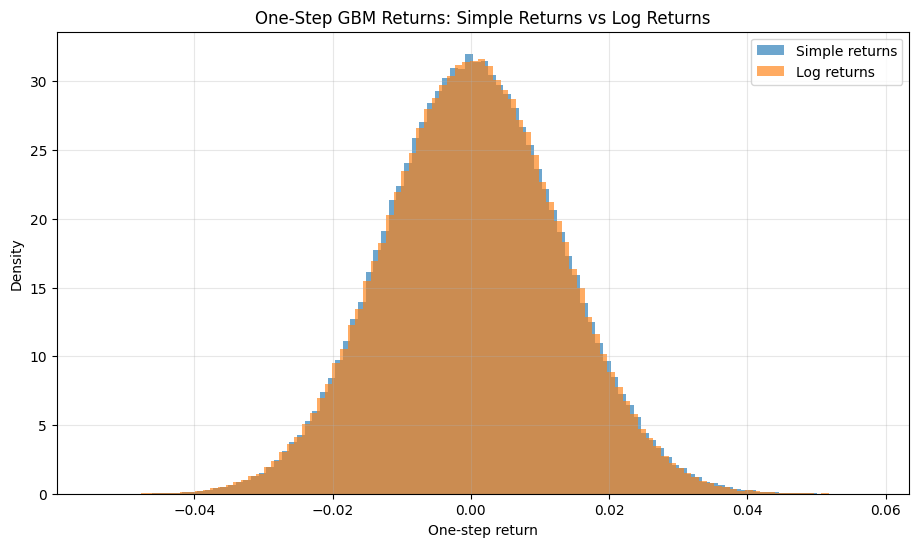

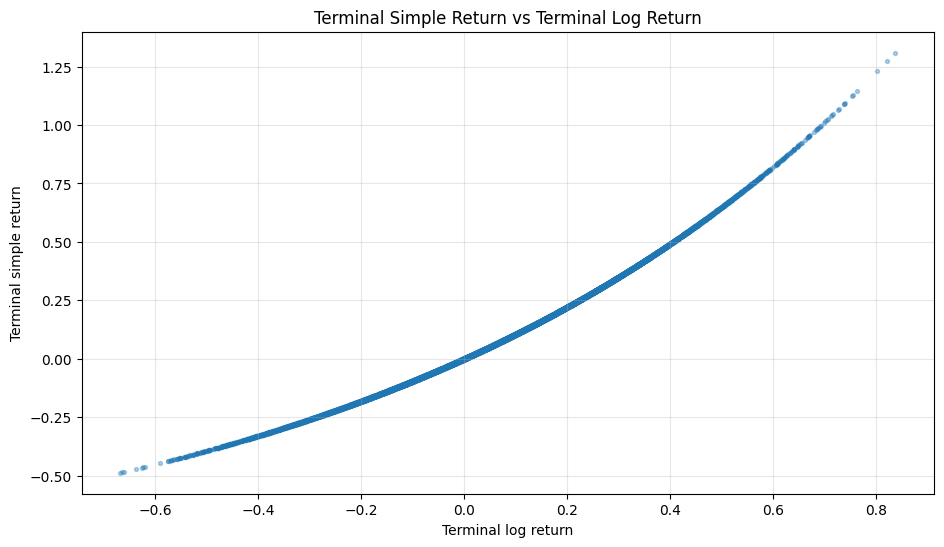

In [10]:
# ============================================================
# Arithmetic returns vs log returns under GBM
# ============================================================

def gbm_return_audit(price_paths: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compare simple returns and log returns.

    For a price process S_t:

        simple return over one step:
            R_t = S_t / S_{t-1} - 1

        log return over one step:
            r_t = log(S_t / S_{t-1})

    Log returns are additive across time:

        sum log(S_t / S_{t-1}) = log(S_T / S_0)

    Simple returns are not additive. They compound:

        prod(1 + R_t) - 1 = S_T / S_0 - 1
    """
    prices = np.asarray(price_paths, dtype=float)

    if prices.ndim != 2:
        raise ValueError(f"price_paths must be 2D. Got shape {prices.shape}.")

    if np.any(prices <= 0) or not np.all(np.isfinite(prices)):
        raise ValueError("All prices must be finite and strictly positive.")

    simple_returns = prices[:, 1:] / prices[:, :-1] - 1.0
    log_returns = np.log(prices[:, 1:] / prices[:, :-1])

    terminal_simple_return = prices[:, -1] / prices[:, 0] - 1.0
    compounded_simple_return = np.prod(1.0 + simple_returns, axis=1) - 1.0
    summed_simple_return = np.sum(simple_returns, axis=1)

    terminal_log_return = np.log(prices[:, -1] / prices[:, 0])
    summed_log_return = np.sum(log_returns, axis=1)

    audit = pd.DataFrame(
        {
            "quantity": [
                "mean_one_step_simple_return",
                "mean_one_step_log_return",
                "std_one_step_simple_return",
                "std_one_step_log_return",
                "terminal_simple_return_mean",
                "terminal_log_return_mean",
                "max_abs_log_additivity_error",
                "max_abs_simple_compounding_error",
                "mean_abs_error_from_summing_simple_returns",
            ],
            "value": [
                float(simple_returns.mean()),
                float(log_returns.mean()),
                float(simple_returns.std(ddof=1)),
                float(log_returns.std(ddof=1)),
                float(terminal_simple_return.mean()),
                float(terminal_log_return.mean()),
                float(np.max(np.abs(summed_log_return - terminal_log_return))),
                float(np.max(np.abs(compounded_simple_return - terminal_simple_return))),
                float(np.mean(np.abs(summed_simple_return - terminal_simple_return))),
            ],
        }
    )

    sample_idx = np.arange(min(10, prices.shape[0]))

    path_level_audit = pd.DataFrame(
        {
            "path": sample_idx,
            "terminal_simple_return": terminal_simple_return[sample_idx],
            "compounded_simple_return": compounded_simple_return[sample_idx],
            "sum_simple_returns": summed_simple_return[sample_idx],
            "terminal_log_return": terminal_log_return[sample_idx],
            "sum_log_returns": summed_log_return[sample_idx],
            "log_additivity_error": (
                summed_log_return[sample_idx] - terminal_log_return[sample_idx]
            ),
            "simple_sum_error": (
                summed_simple_return[sample_idx] - terminal_simple_return[sample_idx]
            ),
        }
    )

    return audit, path_level_audit


return_audit, return_path_audit = gbm_return_audit(gbm_price_paths)

display(return_audit)
display(return_path_audit)


simple_returns = gbm_price_paths[:, 1:] / gbm_price_paths[:, :-1] - 1.0
log_returns = np.diff(np.log(gbm_price_paths), axis=1)

simple_return_sample = simple_returns.ravel()
log_return_sample = log_returns.ravel()

sample_size = min(300_000, simple_return_sample.size)
sample_idx = rng.choice(simple_return_sample.size, size=sample_size, replace=False)

plt.figure(figsize=(11, 6))
plt.hist(simple_return_sample[sample_idx], bins=100, density=True, alpha=0.65, label="Simple returns")
plt.hist(log_return_sample[sample_idx], bins=100, density=True, alpha=0.65, label="Log returns")
plt.title("One-Step GBM Returns: Simple Returns vs Log Returns")
plt.xlabel("One-step return")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


terminal_simple_returns = gbm_price_paths[:, -1] / gbm_price_paths[:, 0] - 1.0
terminal_log_returns = np.log(gbm_price_paths[:, -1] / gbm_price_paths[:, 0])

plt.figure(figsize=(11, 6))
plt.scatter(terminal_log_returns, terminal_simple_returns, s=8, alpha=0.35)
plt.title("Terminal Simple Return vs Terminal Log Return")
plt.xlabel("Terminal log return")
plt.ylabel("Terminal simple return")
plt.grid(True, alpha=0.3)
plt.show()

,quantity,value
0,terminal_actual_log_return_mean,0.059033
1,terminal_ito_log_return_mean,0.059033
2,terminal_naive_log_return_mean,0.079033
3,expected_ito_correction,-0.020000
4,mean_naive_minus_actual,0.020000
5,max_abs_actual_minus_ito_path_error,0.000000
6,mean_abs_naive_terminal_error,0.020000


,path,actual_terminal_log_return,ito_terminal_log_return,naive_terminal_log_return,naive_minus_actual
0,0,0.091134,0.091134,0.111134,0.020000
1,1,-0.058397,-0.058397,-0.038397,0.020000
2,2,0.253257,0.253257,0.273257,0.020000
3,3,0.462739,0.462739,0.482739,0.020000
4,4,0.047236,0.047236,0.067236,0.020000
5,5,0.026987,0.026987,0.046987,0.020000
6,6,0.362193,0.362193,0.382193,0.020000
7,7,0.048908,0.048908,0.068908,0.020000
8,8,-0.055872,-0.055872,-0.035872,0.020000
9,9,0.130502,0.130502,0.150502,0.020000


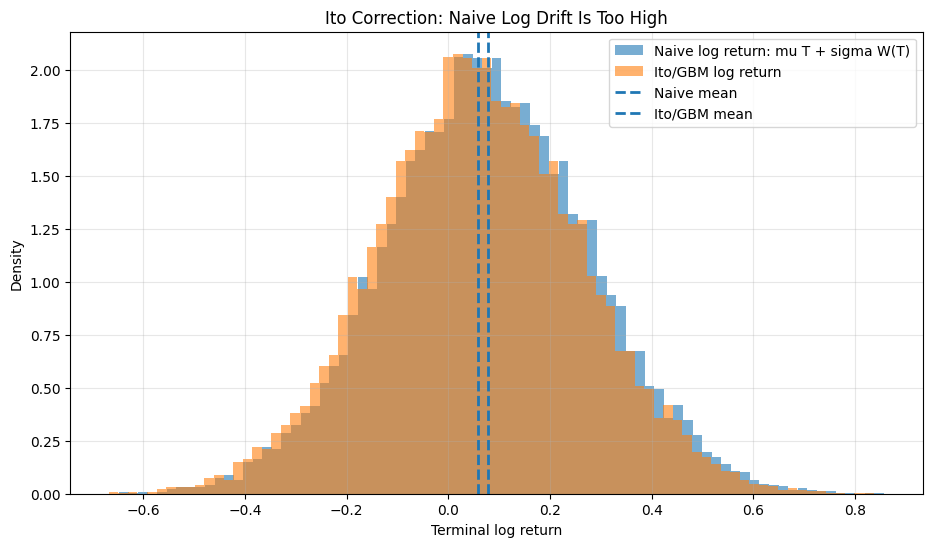

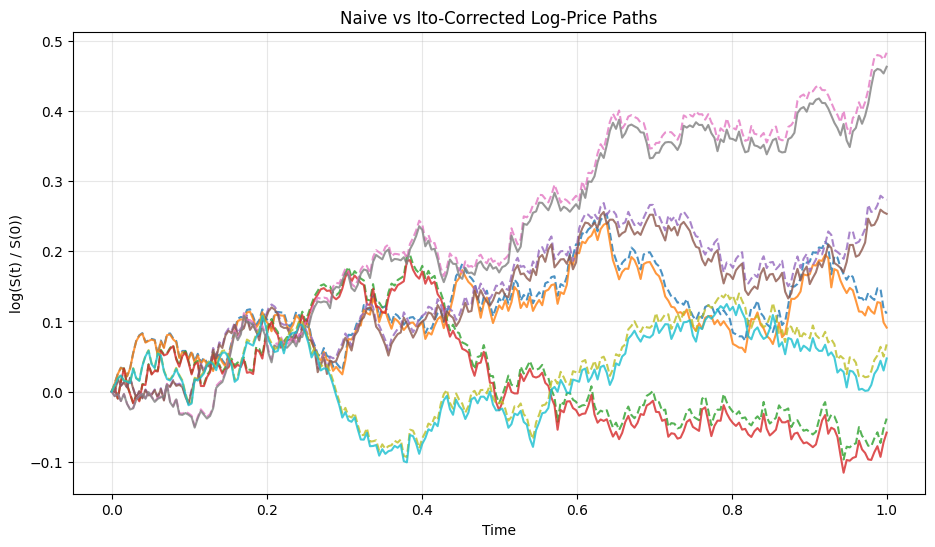

In [11]:
# ============================================================
# Ito correction preview: why log GBM drift is mu - 0.5 sigma^2
# ============================================================

def ito_correction_audit(
    gbm_config: GBMSimulationConfig,
    gbm_increments: np.ndarray,
    gbm_log_price_paths: np.ndarray,
    time_grid: np.ndarray,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Show the Ito correction numerically.

    GBM is:

        dS_t = mu S_t dt + sigma S_t dW_t

    A naive ordinary-calculus guess would say:

        d log(S_t) ≈ dS_t / S_t
        d log(S_t) ≈ mu dt + sigma dW_t

    But Ito's lemma gives:

        d log(S_t) = (mu - 0.5 sigma^2) dt + sigma dW_t

    The missing term is caused by Brownian quadratic variation.
    """
    W_paths = np.empty((gbm_increments.shape[0], gbm_increments.shape[1] + 1), dtype=float)
    W_paths[:, 0] = 0.0
    W_paths[:, 1:] = np.cumsum(gbm_increments, axis=1)

    naive_log_paths = gbm_config.mu * time_grid[None, :] + gbm_config.sigma * W_paths

    ito_log_paths = (
        (gbm_config.mu - 0.5 * gbm_config.sigma**2) * time_grid[None, :]
        + gbm_config.sigma * W_paths
    )

    actual_log_paths = gbm_log_price_paths

    terminal_actual = actual_log_paths[:, -1]
    terminal_ito = ito_log_paths[:, -1]
    terminal_naive = naive_log_paths[:, -1]

    expected_ito_correction = -0.5 * gbm_config.sigma**2 * gbm_config.T
    realized_naive_minus_actual = terminal_naive - terminal_actual

    summary = pd.DataFrame(
        {
            "quantity": [
                "terminal_actual_log_return_mean",
                "terminal_ito_log_return_mean",
                "terminal_naive_log_return_mean",
                "expected_ito_correction",
                "mean_naive_minus_actual",
                "max_abs_actual_minus_ito_path_error",
                "mean_abs_naive_terminal_error",
            ],
            "value": [
                float(terminal_actual.mean()),
                float(terminal_ito.mean()),
                float(terminal_naive.mean()),
                expected_ito_correction,
                float(realized_naive_minus_actual.mean()),
                float(np.max(np.abs(actual_log_paths - ito_log_paths))),
                float(np.mean(np.abs(terminal_naive - terminal_actual))),
            ],
        }
    )

    sample_paths = np.arange(min(10, actual_log_paths.shape[0]))

    path_level = pd.DataFrame(
        {
            "path": sample_paths,
            "actual_terminal_log_return": terminal_actual[sample_paths],
            "ito_terminal_log_return": terminal_ito[sample_paths],
            "naive_terminal_log_return": terminal_naive[sample_paths],
            "naive_minus_actual": realized_naive_minus_actual[sample_paths],
        }
    )

    return summary, path_level


ito_audit, ito_path_audit = ito_correction_audit(
    gbm_config=gbm_config,
    gbm_increments=gbm_increments,
    gbm_log_price_paths=gbm_log_price_paths,
    time_grid=gbm_time_grid,
)

display(ito_audit)
display(ito_path_audit)


terminal_actual_log_returns = gbm_log_price_paths[:, -1]

W_terminal = np.sum(gbm_increments, axis=1)
terminal_naive_log_returns = (
    gbm_config.mu * gbm_config.T
    + gbm_config.sigma * W_terminal
)

plt.figure(figsize=(11, 6))
plt.hist(terminal_naive_log_returns, bins=80, density=True, alpha=0.60, label="Naive log return: mu T + sigma W(T)")
plt.hist(terminal_actual_log_returns, bins=80, density=True, alpha=0.60, label="Ito/GBM log return")
plt.axvline(
    terminal_naive_log_returns.mean(),
    linestyle="--",
    linewidth=2.0,
    label="Naive mean",
)
plt.axvline(
    terminal_actual_log_returns.mean(),
    linestyle="--",
    linewidth=2.0,
    label="Ito/GBM mean",
)
plt.title("Ito Correction: Naive Log Drift Is Too High")
plt.xlabel("Terminal log return")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


sample_path_count = 5

plt.figure(figsize=(11, 6))
for path_idx in range(sample_path_count):
    W_path = np.r_[0.0, np.cumsum(gbm_increments[path_idx])]
    naive_path = gbm_config.mu * gbm_time_grid + gbm_config.sigma * W_path
    actual_path = gbm_log_price_paths[path_idx]

    plt.plot(gbm_time_grid, naive_path, linestyle="--", linewidth=1.5, alpha=0.8)
    plt.plot(gbm_time_grid, actual_path, linewidth=1.5, alpha=0.8)

plt.title("Naive vs Ito-Corrected Log-Price Paths")
plt.xlabel("Time")
plt.ylabel("log(S(t) / S(0))")
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
# ============================================================
# Final notebook audit
# ============================================================

def extract_audit_value(
    audit: pd.DataFrame,
    key_column: str,
    key: str,
    value_column: str,
) -> float:
    """Extract one scalar value from an audit table."""
    matched = audit.loc[audit[key_column] == key, value_column]

    if matched.empty:
        raise KeyError(f"Could not find key={key!r} in column={key_column!r}.")

    if len(matched) != 1:
        raise ValueError(f"Expected one match for key={key!r}, found {len(matched)}.")

    return float(matched.iloc[0])


def build_final_notebook_audit() -> pd.DataFrame:
    """
    Build final pass/fail checks for the notebook.

    These checks are simulation diagnostics, not mathematical proofs.
    They verify that the implementation behaves consistently with the
    Brownian and GBM facts needed before moving to Ito's lemma.
    """
    brownian_terminal_mean_error = extract_audit_value(
        terminal_audit,
        "quantity",
        "terminal_mean",
        "absolute_error",
    )
    brownian_terminal_variance_error = extract_audit_value(
        terminal_audit,
        "quantity",
        "terminal_variance",
        "absolute_error",
    )

    standardized_increment_mean_error = extract_audit_value(
        increment_audit,
        "quantity",
        "standardized_increment_mean",
        "absolute_error",
    )
    standardized_increment_variance_error = extract_audit_value(
        increment_audit,
        "quantity",
        "standardized_increment_variance",
        "absolute_error",
    )
    adjacent_increment_corr = abs(
        extract_audit_value(
            increment_audit,
            "quantity",
            "adjacent_increment_corr",
            "empirical",
        )
    )

    max_time_scaling_variance_error = float(
        time_scaling_audit["variance_abs_error"].max()
    )

    max_qv_mean_error = float(
        variation_audit["qv_mean_abs_error"].max()
    )
    absolute_variation_grows = bool(
        variation_audit["abs_variation_mean"].iloc[-1]
        > 10.0 * variation_audit["abs_variation_mean"].iloc[0]
    )

    gbm_log_mean_error = extract_audit_value(
        gbm_audit,
        "quantity",
        "terminal_log_return_mean",
        "absolute_error",
    )
    gbm_log_variance_error = extract_audit_value(
        gbm_audit,
        "quantity",
        "terminal_log_return_variance",
        "absolute_error",
    )
    gbm_price_mean_error = extract_audit_value(
        gbm_audit,
        "quantity",
        "terminal_price_mean",
        "absolute_error",
    )
    gbm_price_mean_relative_error = gbm_price_mean_error / extract_audit_value(
        gbm_audit,
        "quantity",
        "terminal_price_mean",
        "theoretical",
    )

    log_additivity_error = extract_audit_value(
        return_audit,
        "quantity",
        "max_abs_log_additivity_error",
        "value",
    )
    simple_sum_error = extract_audit_value(
        return_audit,
        "quantity",
        "mean_abs_error_from_summing_simple_returns",
        "value",
    )

    max_actual_minus_ito_error = extract_audit_value(
        ito_audit,
        "quantity",
        "max_abs_actual_minus_ito_path_error",
        "value",
    )
    mean_naive_minus_actual = extract_audit_value(
        ito_audit,
        "quantity",
        "mean_naive_minus_actual",
        "value",
    )
    expected_naive_minus_actual = 0.5 * gbm_config.sigma**2 * gbm_config.T

    checks = [
        {
            "check": "Brownian terminal mean is near 0",
            "value": brownian_terminal_mean_error,
            "threshold": 0.020000,
            "passed": brownian_terminal_mean_error < 0.020000,
        },
        {
            "check": "Brownian terminal variance is near T",
            "value": brownian_terminal_variance_error,
            "threshold": 0.020000,
            "passed": brownian_terminal_variance_error < 0.020000,
        },
        {
            "check": "Standardized Brownian increment mean is near 0",
            "value": standardized_increment_mean_error,
            "threshold": 0.005000,
            "passed": standardized_increment_mean_error < 0.005000,
        },
        {
            "check": "Standardized Brownian increment variance is near 1",
            "value": standardized_increment_variance_error,
            "threshold": 0.005000,
            "passed": standardized_increment_variance_error < 0.005000,
        },
        {
            "check": "Adjacent Brownian increment correlation is near 0",
            "value": adjacent_increment_corr,
            "threshold": 0.005000,
            "passed": adjacent_increment_corr < 0.005000,
        },
        {
            "check": "Brownian variance scales approximately linearly with time",
            "value": max_time_scaling_variance_error,
            "threshold": 0.020000,
            "passed": max_time_scaling_variance_error < 0.020000,
        },
        {
            "check": "Brownian quadratic variation remains near T",
            "value": max_qv_mean_error,
            "threshold": 0.015000,
            "passed": max_qv_mean_error < 0.015000,
        },
        {
            "check": "Brownian absolute variation grows under refinement",
            "value": float(variation_audit["abs_variation_mean"].iloc[-1]),
            "threshold": float(10.0 * variation_audit["abs_variation_mean"].iloc[0]),
            "passed": absolute_variation_grows,
        },
        {
            "check": "GBM terminal log-return mean matches theory",
            "value": gbm_log_mean_error,
            "threshold": 0.005000,
            "passed": gbm_log_mean_error < 0.005000,
        },
        {
            "check": "GBM terminal log-return variance matches theory",
            "value": gbm_log_variance_error,
            "threshold": 0.003000,
            "passed": gbm_log_variance_error < 0.003000,
        },
        {
            "check": "GBM terminal price mean matches theory",
            "value": gbm_price_mean_relative_error,
            "threshold": 0.003000,
            "passed": gbm_price_mean_relative_error < 0.003000,
        },
        {
            "check": "Log returns are additive",
            "value": log_additivity_error,
            "threshold": EXACT_TOL,
            "passed": log_additivity_error < EXACT_TOL,
        },
        {
            "check": "Simple returns are not additive",
            "value": simple_sum_error,
            "threshold": 0.005000,
            "passed": simple_sum_error > 0.005000,
        },
        {
            "check": "Ito-corrected log path equals simulated GBM log path",
            "value": max_actual_minus_ito_error,
            "threshold": EXACT_TOL,
            "passed": max_actual_minus_ito_error < EXACT_TOL,
        },
        {
            "check": "Naive log drift exceeds Ito log drift by 0.5 sigma^2 T",
            "value": abs(mean_naive_minus_actual - expected_naive_minus_actual),
            "threshold": EXACT_TOL,
            "passed": abs(mean_naive_minus_actual - expected_naive_minus_actual) < EXACT_TOL,
        },
    ]

    return pd.DataFrame(checks)


final_audit = build_final_notebook_audit()
display(final_audit)

notebook_passed = bool(final_audit["passed"].all())

print(f"Notebook passed: {notebook_passed}")

if not notebook_passed:
    failed_checks = final_audit.loc[~final_audit["passed"], "check"].tolist()
    raise AssertionError(f"Notebook failed checks: {failed_checks}")

,check,value,threshold,passed
0,Brownian terminal mean is near 0,0.005543,0.020000,True
1,Brownian terminal variance is near T,0.005439,0.020000,True
2,Standardized Brownian increment mean is near 0,0.000349,0.005000,True
3,Standardized Brownian increment variance is ne...,0.000700,0.005000,True
4,Adjacent Brownian increment correlation is near 0,0.000506,0.005000,True
5,Brownian variance scales approximately linearl...,0.007744,0.020000,True
6,Brownian quadratic variation remains near T,0.007584,0.015000,True
7,Brownian absolute variation grows under refine...,51.057873,31.906304,True
8,GBM terminal log-return mean matches theory,0.000967,0.005000,True
9,GBM terminal log-return variance matches theory,0.000407,0.003000,True


Notebook passed: True


In [13]:
# ============================================================
# Final notebook audit and handoff
# ============================================================

def get_metric(
    table: pd.DataFrame,
    key_col: str,
    key: str,
    value_col: str,
) -> float:
    """Extract one numeric metric from an audit table."""
    match = table.loc[table[key_col].eq(key), value_col]

    if match.empty:
        raise KeyError(f"Missing metric: {key!r}")

    if len(match) != 1:
        raise ValueError(f"Metric {key!r} is not unique.")

    value = float(match.iloc[0])

    if not np.isfinite(value):
        raise ValueError(f"Metric {key!r} is not finite: {value}")

    return value


def pass_if_less(name: str, value: float, threshold: float) -> dict[str, object]:
    """Create a pass/fail row for a less-than threshold."""
    return {
        "check": name,
        "value": value,
        "rule": f"< {threshold:g}",
        "passed": bool(value < threshold),
    }


def pass_if_greater(name: str, value: float, threshold: float) -> dict[str, object]:
    """Create a pass/fail row for a greater-than threshold."""
    return {
        "check": name,
        "value": value,
        "rule": f"> {threshold:g}",
        "passed": bool(value > threshold),
    }


def pass_if_close(
    name: str,
    value: float,
    target: float,
    tolerance: float,
) -> dict[str, object]:
    """Create a pass/fail row for absolute closeness to a target."""
    error = abs(value - target)

    return {
        "check": name,
        "value": value,
        "target": target,
        "abs_error": error,
        "rule": f"abs_error < {tolerance:g}",
        "passed": bool(error < tolerance),
    }


def build_final_audit() -> pd.DataFrame:
    """Collect final notebook diagnostics into one pass/fail table."""
    rows: list[dict[str, object]] = []

    # --------------------------------------------------------
    # Brownian terminal distribution
    # --------------------------------------------------------

    rows.append(
        pass_if_less(
            name="Brownian terminal mean is close to 0",
            value=get_metric(
                terminal_audit,
                key_col="quantity",
                key="terminal_mean",
                value_col="absolute_error",
            ),
            threshold=0.02,
        )
    )

    rows.append(
        pass_if_less(
            name="Brownian terminal variance is close to T",
            value=get_metric(
                terminal_audit,
                key_col="quantity",
                key="terminal_variance",
                value_col="absolute_error",
            ),
            threshold=0.02,
        )
    )

    # --------------------------------------------------------
    # Brownian increment behavior
    # --------------------------------------------------------

    rows.append(
        pass_if_less(
            name="Standardized Brownian increment mean is close to 0",
            value=get_metric(
                increment_audit,
                key_col="quantity",
                key="standardized_increment_mean",
                value_col="absolute_error",
            ),
            threshold=0.005,
        )
    )

    rows.append(
        pass_if_less(
            name="Standardized Brownian increment variance is close to 1",
            value=get_metric(
                increment_audit,
                key_col="quantity",
                key="standardized_increment_variance",
                value_col="absolute_error",
            ),
            threshold=0.005,
        )
    )

    rows.append(
        pass_if_less(
            name="Adjacent Brownian increment correlation is close to 0",
            value=abs(
                get_metric(
                    increment_audit,
                    key_col="quantity",
                    key="adjacent_increment_corr",
                    value_col="empirical",
                )
            ),
            threshold=0.005,
        )
    )

    # --------------------------------------------------------
    # Brownian time scaling
    # --------------------------------------------------------

    rows.append(
        pass_if_less(
            name="Brownian variance scales approximately linearly with time",
            value=float(time_scaling_audit["variance_abs_error"].max()),
            threshold=0.02,
        )
    )

    # --------------------------------------------------------
    # Quadratic variation and absolute variation
    # --------------------------------------------------------

    rows.append(
        pass_if_less(
            name="Mean realized quadratic variation stays close to T",
            value=float(variation_audit["qv_mean_abs_error"].max()),
            threshold=0.015,
        )
    )

    abs_var_first = float(variation_audit["abs_variation_mean"].iloc[0])
    abs_var_last = float(variation_audit["abs_variation_mean"].iloc[-1])
    abs_var_growth_ratio = abs_var_last / abs_var_first

    rows.append(
        pass_if_greater(
            name="Absolute variation grows under partition refinement",
            value=abs_var_growth_ratio,
            threshold=10.0,
        )
    )

    # --------------------------------------------------------
    # GBM terminal distribution
    # --------------------------------------------------------

    rows.append(
        pass_if_less(
            name="GBM terminal log-return mean matches theory",
            value=get_metric(
                gbm_audit,
                key_col="quantity",
                key="terminal_log_return_mean",
                value_col="absolute_error",
            ),
            threshold=0.005,
        )
    )

    rows.append(
        pass_if_less(
            name="GBM terminal log-return variance matches theory",
            value=get_metric(
                gbm_audit,
                key_col="quantity",
                key="terminal_log_return_variance",
                value_col="absolute_error",
            ),
            threshold=0.003,
        )
    )

    gbm_price_mean_error = get_metric(
        gbm_audit,
        key_col="quantity",
        key="terminal_price_mean",
        value_col="absolute_error",
    )
    gbm_price_mean_theory = get_metric(
        gbm_audit,
        key_col="quantity",
        key="terminal_price_mean",
        value_col="theoretical",
    )
    gbm_price_mean_relative_error = gbm_price_mean_error / gbm_price_mean_theory

    rows.append(
        pass_if_less(
            name="GBM terminal price mean matches theory in relative terms",
            value=gbm_price_mean_relative_error,
            threshold=0.003,
        )
    )

    # --------------------------------------------------------
    # Return arithmetic
    # --------------------------------------------------------

    rows.append(
        pass_if_less(
            name="Log returns add exactly up to terminal log return",
            value=get_metric(
                return_audit,
                key_col="quantity",
                key="max_abs_log_additivity_error",
                value_col="value",
            ),
            threshold=1e-10,
        )
    )

    rows.append(
        pass_if_greater(
            name="Simple returns are not additive across time",
            value=get_metric(
                return_audit,
                key_col="quantity",
                key="mean_abs_error_from_summing_simple_returns",
                value_col="value",
            ),
            threshold=0.005,
        )
    )

    # --------------------------------------------------------
    # Ito correction preview
    # --------------------------------------------------------

    rows.append(
        pass_if_less(
            name="Ito-corrected log path matches exact GBM log path",
            value=get_metric(
                ito_audit,
                key_col="quantity",
                key="max_abs_actual_minus_ito_path_error",
                value_col="value",
            ),
            threshold=1e-10,
        )
    )

    observed_naive_minus_actual = get_metric(
        ito_audit,
        key_col="quantity",
        key="mean_naive_minus_actual",
        value_col="value",
    )
    expected_naive_minus_actual = 0.5 * gbm_config.sigma**2 * gbm_config.T

    rows.append(
        pass_if_close(
            name="Naive log drift exceeds Ito log drift by 0.5 sigma^2 T",
            value=observed_naive_minus_actual,
            target=expected_naive_minus_actual,
            tolerance=1e-10,
        )
    )

    return pd.DataFrame(rows)


final_audit = build_final_audit()

display(final_audit)

notebook_passed = bool(final_audit["passed"].all())
print(f"Notebook passed: {notebook_passed}")

if not notebook_passed:
    failed = final_audit.loc[~final_audit["passed"], "check"].tolist()
    raise AssertionError(f"Notebook failed these checks: {failed}")


handoff_summary = pd.DataFrame(
    {
        "completed_foundation": [
            "Brownian terminal distribution",
            "Brownian increment behavior",
            "Brownian time scaling",
            "Quadratic variation",
            "Geometric Brownian motion",
            "Arithmetic vs log returns",
            "Ito correction preview",
        ],
        "status": [
            "passed",
            "passed",
            "passed",
            "passed",
            "passed",
            "passed",
            "passed",
        ],
        "why_it_matters_next": [
            "Needed for continuous-time uncertainty.",
            "Needed for stochastic integration.",
            "Needed for volatility scaling.",
            "Explains why Ito calculus keeps second-order terms.",
            "Defines the stock process used by Black-Scholes.",
            "Explains why log-price dynamics are easier to model.",
            "Prepares the derivation of Ito's lemma and the Black-Scholes PDE.",
        ],
    }
)

display(handoff_summary)

print("Next notebook: 03_ito_lemma_and_black_scholes_pde.ipynb")

,check,value,rule,passed,target,abs_error
0,Brownian terminal mean is close to 0,0.005543,< 0.02,True,NaN,NaN
1,Brownian terminal variance is close to T,0.005439,< 0.02,True,NaN,NaN
2,Standardized Brownian increment mean is close ...,0.000349,< 0.005,True,NaN,NaN
3,Standardized Brownian increment variance is cl...,0.000700,< 0.005,True,NaN,NaN
4,Adjacent Brownian increment correlation is clo...,0.000506,< 0.005,True,NaN,NaN
5,Brownian variance scales approximately linearl...,0.007744,< 0.02,True,NaN,NaN
6,Mean realized quadratic variation stays close ...,0.007584,< 0.015,True,NaN,NaN
7,Absolute variation grows under partition refin...,16.002440,> 10,True,NaN,NaN
8,GBM terminal log-return mean matches theory,0.000967,< 0.005,True,NaN,NaN
9,GBM terminal log-return variance matches theory,0.000407,< 0.003,True,NaN,NaN


Notebook passed: True


,completed_foundation,status,why_it_matters_next
0,Brownian terminal distribution,passed,Needed for continuous-time uncertainty.
1,Brownian increment behavior,passed,Needed for stochastic integration.
2,Brownian time scaling,passed,Needed for volatility scaling.
3,Quadratic variation,passed,Explains why Ito calculus keeps second-order t...
4,Geometric Brownian motion,passed,Defines the stock process used by Black-Scholes.
5,Arithmetic vs log returns,passed,Explains why log-price dynamics are easier to ...
6,Ito correction preview,passed,Prepares the derivation of Ito's lemma and the...


Next notebook: 03_ito_lemma_and_black_scholes_pde.ipynb
